# 03: EDA & Feature Engineering (Phase 3)

Original 6-fund exploratory work: real CAGR, rolling CAGR across multiple
holding periods, and the risk/return patterns that motivated everything
downstream (risk-adjusted scoring in Phase 4, quantile regression in
Phase 5, and later the 138-fund expansion in `05`).

This notebook is unchanged from the original working version -- split out
of a combined EDA+modeling notebook so Phase 3 (exploration) and Phase 4/5
(modeling) live separately. Modeling work now lives in
`04_modeling_risk_scoring.ipynb`.

# Phase 3: EDA & Feature Engineering



Computed real CAGR, rolling CAGR, and volatility (std dev) from actual 

NAV history for all 6 funds, replacing the placeholder rates used in 

Phase 2's baseline.



## What was built

- `calculate_cagr()` — full-period CAGR from first to last NAV

- `calculate_rolling_cagr()` — CAGR for every possible N-year window in 

  a fund's history, using actual calendar dates (not row-count 

  approximation) to correctly handle non-trading days

- Risk/return summary table and scatter plot (5yr rolling windows)

- Multi-horizon comparison across 1/3/5/7/10-year windows



## Key findings

- Replacing Phase 2's guessed rates with real CAGR changed the 

  recommended "best" fund from sbi_large_cap to icici_large_cap — 

  proof the static baseline could recommend a suboptimal option.

- Corporate bond funds show low, flat volatility regardless of holding 

  period (~1% std). Equity fund volatility drops sharply as holding 

  period increases (e.g. hdfc_large_cap: ~20% std at 1yr -> ~2-5% std 

  at 5-10yr).

- Worst-case (min) rolling return for equity funds improves 

  dramatically with longer holding periods — e.g. hdfc_large_cap's 

  worst 1-year window was -37%, but no 7+ year window in this dataset 

  was ever negative. This is the core evidence for why holding period 

  should influence recommendations.

- Mean rolling CAGR for equity funds shows a "dip then recovery" 

  pattern across window lengths (high at 1yr, lowest around 5-7yr, 

  ticks back up at 10yr). Likely driven by which specific historical 

  periods each window length happens to average over — not fully 

  explained, noted as an observation.

- icici_large_cap was consistently the top or near-top performer 

  across every

In [1]:
import pandas as pd

import numpy as np

import os

import matplotlib.pyplot as plt




In [2]:
fund_names = ['hdfc_large_cap', 'hdfc_corporate_bond', 'hdfc_hybrid_equity',

              'sbi_large_cap', 'icici_large_cap', 'icici_corporate_bond']



data = {} # all csv data is stored in here to access in python



for name in fund_names:

    df = pd.read_csv(f"../Data/raw/{name}.csv")

    df['date'] = pd.to_datetime(df['date']) # converts string value in db to datetime object

    data[name] = df



print(data.keys())

dict_keys(['hdfc_large_cap', 'hdfc_corporate_bond', 'hdfc_hybrid_equity', 'sbi_large_cap', 'icici_large_cap', 'icici_corporate_bond'])


In [3]:
def calculate_cagr(df):

    nav_start = df['nav'].iloc[0]

    nav_end = df['nav'].iloc[-1]



    date_start = df['date'].iloc[0]

    date_end = df['date'].iloc[-1]



    years = (date_end - date_start).days / 365.25 # accounting for leap years



    return (nav_end / nav_start )**(1/years) -1

'''One small thing worth noting: you'll see np.float64(...) wrapping every number instead of a plain 

float like 0.1322.... That's just numpy's own float type — pandas operations (like .iloc, division, **)

 tend to return numpy types rather than pure Python floats under the hood. Functionally it behaves 

 identically to a regular float in all your math and comparisons; it's just how it displays when 

 printed raw inside a dict. Nothing to fix.'''


"One small thing worth noting: you'll see np.float64(...) wrapping every number instead of a plain \n\nfloat like 0.1322.... That's just numpy's own float type — pandas operations (like .iloc, division, **)\n\n tend to return numpy types rather than pure Python floats under the hood. Functionally it behaves \n\n identically to a regular float in all your math and comparisons; it's just how it displays when \n\n printed raw inside a dict. Nothing to fix."

In [4]:
# print(calculate_cagr(data['hdfc_large_cap']))

real_rates = {}



for name, df in data.items():

    real_rates[name] = calculate_cagr(df)



print(real_rates)

{'hdfc_large_cap': np.float64(0.1322356312756625), 'hdfc_corporate_bond': np.float64(0.07970769495864638), 'hdfc_hybrid_equity': np.float64(0.11361766804856166), 'sbi_large_cap': np.float64(0.14459174060950164), 'icici_large_cap': np.float64(0.1473384306277543), 'icici_corporate_bond': np.float64(0.08117463419010562)}


In [5]:
import sys

sys.path.append('../src')

from calculators import compound_interest, recommend_best


In [6]:
results, best = recommend_best(10000,10, real_rates)

print(results)

print("Best: ",best)

{'hdfc_large_cap': np.float64(34623.2777280208), 'hdfc_corporate_bond': np.float64(21530.88917479742), 'hdfc_hybrid_equity': np.float64(29333.31364923049), 'sbi_large_cap': np.float64(38592.78118463047), 'icici_large_cap': np.float64(39528.9617233331), 'icici_corporate_bond': np.float64(21825.212462677417)}
Best:  icici_large_cap


In [7]:
# def calculate_rolling_cagr(df, window_years):

#     df =df.copy()

#     df = df.set_index('date')



#     window_days = int(window_years * 365.25)

#     rolling_cagr = []

#     dates = []

#     # goes day by day that what would be the cagr for this date to 5 yr ahead.

#     for i in range(len(df) - window_days):

#         start_nav = df['nav'].iloc[i]

#         end_nav = df['nav'].iloc[i + window_days]

#         cagr = (end_nav/start_nav)**(1/window_years) -1

#         rolling_cagr.append(cagr)

#         dates.append(df.index[i])

#     return pd.Series(rolling_cagr, dates)



def calculate_rolling_cagr(df, window_years):

    df =df.copy()

    df = df.set_index('date')



    rolling_cagr = []

    dates = []



    for i in range(len(df)):

        start_date = df.index[i]

        # dateoffset shifts in acctual calendar years so data is acctually year wise

        target_end_date = start_date + pd.DateOffset(years = window_years)



        if(target_end_date>df.index[-1]):

            break

        # searchsorted does a binary search an return the closest date available near target

        end_idx = df.index.searchsorted(target_end_date)



        start_nav = df['nav'].iloc[i]

        end_nav = df['nav'].iloc[end_idx]



        acctual_years = (df.index[end_idx] - start_date).days/365.25

        cagr = (end_nav /start_nav)**(1/acctual_years) -1

        rolling_cagr.append(cagr)

        dates.append(start_date)

    return pd.Series(rolling_cagr , index = dates)
















this window this by days wont work as it assumes that trade happens 365 days a year which is not true. so 10 year give us nan and doesnt work. TO PREVENT THIS WE'LL HAVE TO SHIFT FROM USING DAYS TO USING ACCTUAL DATES:

In [8]:
rolling_data = calculate_rolling_cagr(data['hdfc_large_cap'], 5)

# print(rolling_data.head())'

# print(rolling_data.tail())'

print(rolling_data.describe())

count    2100.000000
mean        0.141421
std         0.049078
min        -0.014501
25%         0.112769
50%         0.144020
75%         0.168349
max         0.295082
dtype: float64


In [9]:
summary =[]

for name, df in data.items():

    rolling = calculate_rolling_cagr(df, 5)

    summary.append({

        'fund' : name,

        "std" : rolling.std(),

        'mean' : rolling.mean(),

        'min' : rolling.min(),

        'max': rolling.max()

    })

summary_df = pd.DataFrame(summary)

print(summary_df)

                   fund       std      mean       min       max
0        hdfc_large_cap  0.049078  0.141421 -0.014501  0.295082
1   hdfc_corporate_bond  0.008807  0.078948  0.060465  0.094079
2    hdfc_hybrid_equity  0.046076  0.123799 -0.011455  0.241178
3         sbi_large_cap  0.042789  0.146397 -0.002352  0.276756
4       icici_large_cap  0.046533  0.154617  0.000133  0.303411
5  icici_corporate_bond  0.007494  0.078765  0.065429  0.091061


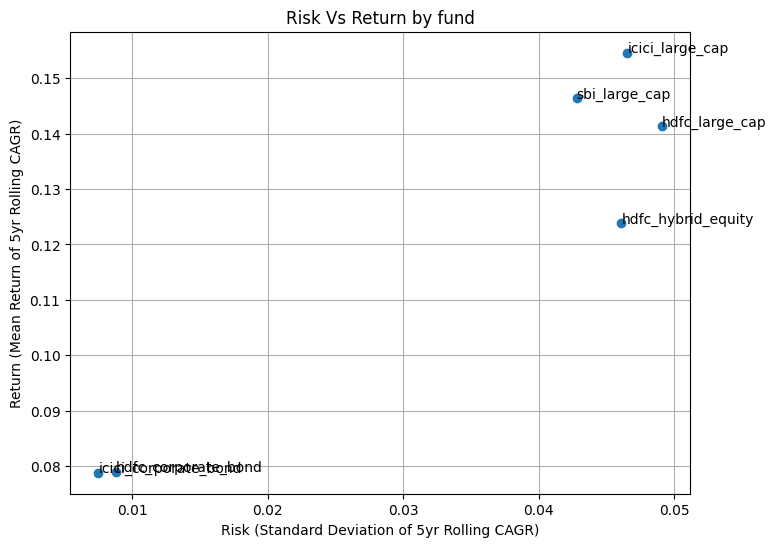

In [10]:
plt.figure(figsize=(8,6))

# scatter is used to show individual points instead of lines.

plt.scatter(summary_df['std'], summary_df['mean'])

# annotate labels those individual points. if u dont u'll see 6 unlabeled dots with no way of differentiating them

for i in range(len(summary_df)):

    plt.annotate(summary_df['fund'].iloc[i],(summary_df['std'].iloc[i], summary_df['mean'].iloc[i]))





plt.xlabel('Risk (Standard Deviation of 5yr Rolling CAGR)')

plt.ylabel('Return (Mean Return of 5yr Rolling CAGR)')

plt.title('Risk Vs Return by fund')

plt.grid(True)

plt.show()

NOW WE HAVE A SUMMARY OF A 5 YR WINDOW. BUT A CUSTOMER WILL NOT ALWAYS BE INVESTING IN A 5 YR WINDOW. IT FLEXIBLE SO WE NEED MORE OPTIONS AND MORE REAILABILITY. SO WE'LL CALCULATE ROLLING CAGR FOR 1 3 5 7 10 YR AND GIVE AS REAILABLE OP AS POSSIBLE

In [11]:
window_list = [x for x in range(1,11)]

all_summary = []



for window in window_list:

    for name, df in data.items():

        rolling = calculate_rolling_cagr(df, window)

        all_summary.append({

            'fund' : name,

            'window_years' : window,

            'std' : rolling.std(),

            'mean': rolling.mean(),

            'min' : rolling.min(),

            'max': rolling.max()

        })

all_summary_df = pd.DataFrame(all_summary)

print(all_summary_df)    

                    fund  window_years       std      mean       min       max
0         hdfc_large_cap             1  0.202796  0.165908 -0.370503  0.909686
1    hdfc_corporate_bond             1  0.025449  0.080809  0.017989  0.132758
2     hdfc_hybrid_equity             1  0.200889  0.151122 -0.262422  0.893053
3          sbi_large_cap             1  0.179314  0.169904 -0.303183  0.981667
4        icici_large_cap             1  0.177664  0.174532 -0.315764  0.928822
5   icici_corporate_bond             1  0.020733  0.081429  0.030581  0.121001
6         hdfc_large_cap             2  0.097973  0.150383 -0.150148  0.503582
7    hdfc_corporate_bond             2  0.018909  0.080870  0.038043  0.118014
8     hdfc_hybrid_equity             2  0.097000  0.133907 -0.130787  0.454401
9          sbi_large_cap             2  0.093568  0.158834 -0.144813  0.506684
10       icici_large_cap             2  0.091915  0.163715 -0.137818  0.522847
11  icici_corporate_bond             2  0.015987  0.

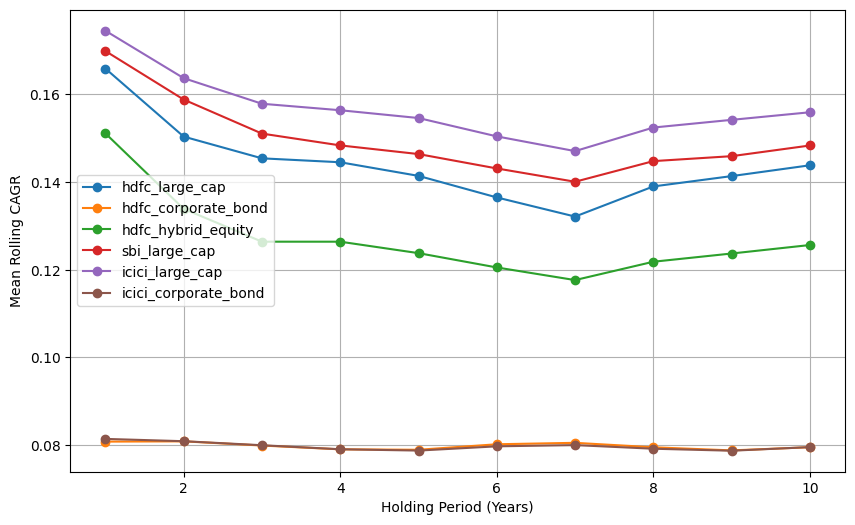

In [12]:
plt.figure(figsize = (10,6))



for name in fund_names:

    fund_data = all_summary_df[all_summary_df['fund'] == name]

    # plot used lines to connet. marker is the icon u see at values, label is used to give names

    # to the box [legend is used to form that box] u see

    plt.plot(fund_data['window_years'], fund_data['mean'], marker = 'o', label = name)

plt.xlabel('Holding Period (Years)')

plt.ylabel('Mean Rolling CAGR')

plt.legend()

plt.grid(True)

plt.show()




In [13]:
long_data = []



for name, df in data.items():

    for window in  window_list:

        rolling = calculate_rolling_cagr(df, window)

        for date, rolling_cagr in rolling.items():

            long_data.append({

                'fund' : name,

                'window_years' : window,

                'start_date': date,

                'cagr' : rolling_cagr

            })



long_df = pd.DataFrame(long_data)

print(long_df.shape)

print(long_df.head())

(117804, 4)
             fund  window_years start_date      cagr
0  hdfc_large_cap             1 2013-01-01  0.034098
1  hdfc_large_cap             1 2013-01-02  0.007658
2  hdfc_large_cap             1 2013-01-03  0.006140
3  hdfc_large_cap             1 2013-01-04  0.001175
4  hdfc_large_cap             1 2013-01-07 -0.003395


The lower part was done because we the 'fund' name is a txt and regression model works on number to give a number output. the get dummies part splits the funds by 0 1 so that model can know which fund it is calculting about. Also the raw start date is also use less as is so we'll also be converting it here or there into someting useful



Also python treats boolen as a subtype of integers so the true false will not cause an issue when we later feed it into the model

In [14]:
long_df_encoded = pd.get_dummies(long_df, columns = ['fund'])

print(long_df_encoded.head())

print(long_df_encoded.columns)

   window_years start_date      cagr  fund_hdfc_corporate_bond  \
0             1 2013-01-01  0.034098                     False   
1             1 2013-01-02  0.007658                     False   
2             1 2013-01-03  0.006140                     False   
3             1 2013-01-04  0.001175                     False   
4             1 2013-01-07 -0.003395                     False   

   fund_hdfc_hybrid_equity  fund_hdfc_large_cap  fund_icici_corporate_bond  \
0                    False                 True                      False   
1                    False                 True                      False   
2                    False                 True                      False   
3                    False                 True                      False   
4                    False                 True                      False   

   fund_icici_large_cap  fund_sbi_large_cap  
0                 False               False  
1                 False               Fals

Since start date isnt acc usefull to us directly or indiretly for the outcome we want we'll drop it

In [15]:
model_df = long_df_encoded.drop(columns = ['start_date'])

print(model_df.head())

print(model_df.columns)

   window_years      cagr  fund_hdfc_corporate_bond  fund_hdfc_hybrid_equity  \
0             1  0.034098                     False                    False   
1             1  0.007658                     False                    False   
2             1  0.006140                     False                    False   
3             1  0.001175                     False                    False   
4             1 -0.003395                     False                    False   

   fund_hdfc_large_cap  fund_icici_corporate_bond  fund_icici_large_cap  \
0                 True                      False                 False   
1                 True                      False                 False   
2                 True                      False                 False   
3                 True                      False                 False   
4                 True                      False                 False   

   fund_sbi_large_cap  
0               False  
1               Fals